# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Suhail Ainur Rofiq | 5054251046 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [171]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
%matplotlib inline
sns.set_theme(style="whitegrid")


In [172]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('bankruptcy.csv')
df.columns = df.columns.str.strip()

df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate            

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [173]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [174]:
df.isnull().sum()

Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
                                                          ..
Liability to Equity                                        0
Degree of Financial Leverage (DFL)                         0
Interest Coverage Ratio (Interest expense to EBIT)         0
Net Income Flag                                            0
Equity to Liability                                        0
Length: 96, dtype: int64

In [175]:
df.duplicated().sum()

np.int64(0)

   Bankrupt?  count
0          0   6599
1          1    220


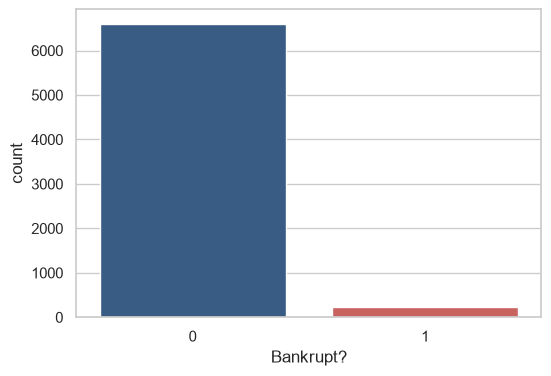

In [176]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Bankrupt?',
    hue='Bankrupt?',
    palette=['#2b5c8f', '#d9534f'],
    legend=False
)

target_counts = df['Bankrupt?'].value_counts().reset_index()

print(target_counts)


Class sangat imbalance, dikarenakan berbanding sangat jauh antara 6599 dengan 220.

In [177]:
corr = df.corr()['Bankrupt?'].abs().sort_values(ascending=False)

top_features = corr.drop('Bankrupt?').head(6).index.tolist()

print(top_features)

['Net Income to Total Assets', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'ROA(C) before interest and depreciation before interest', 'Net worth/Assets', 'Debt ratio %']


## Analisis Univariat

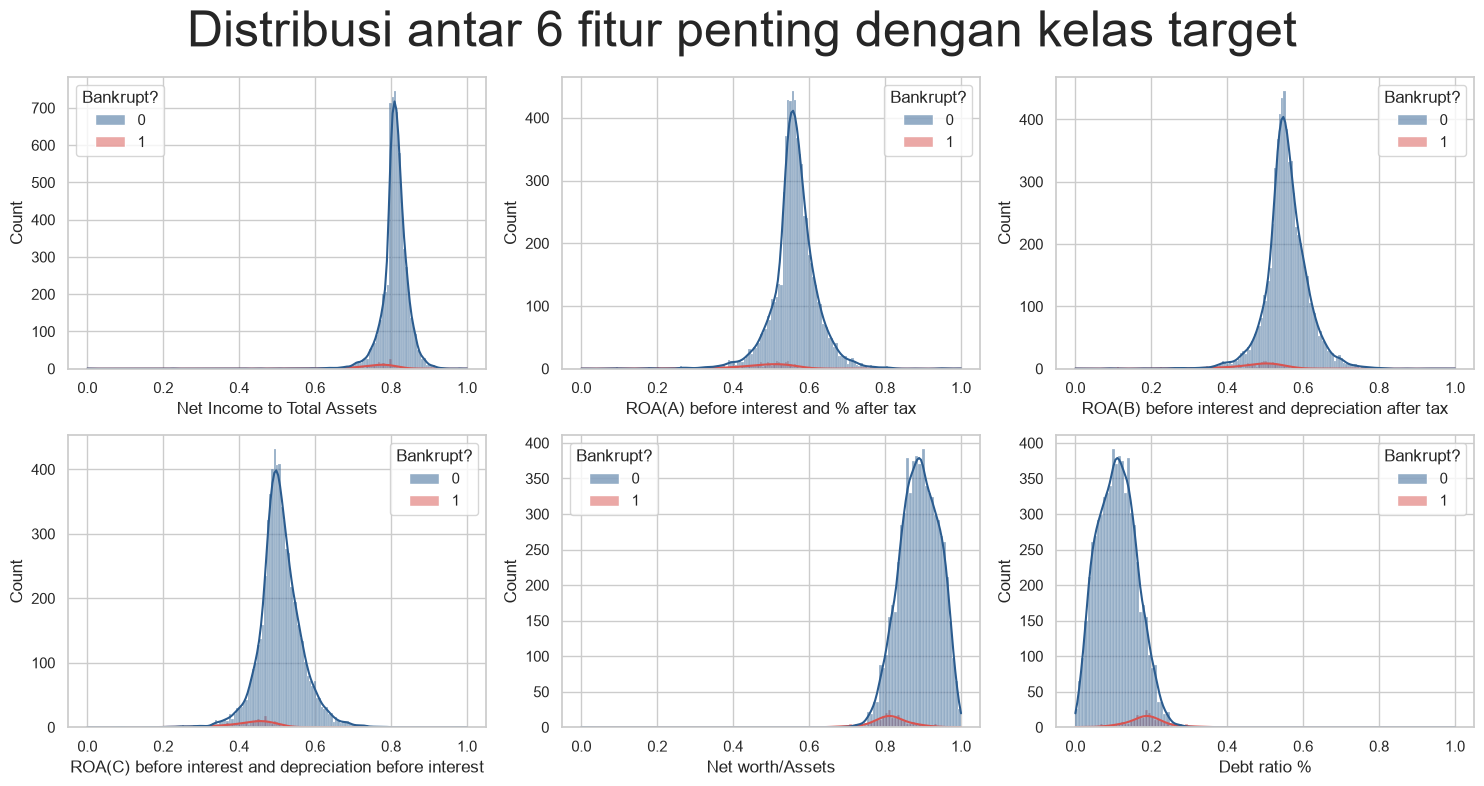

In [178]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
plt.figure(figsize=(15,8))
plt.suptitle("Distribusi antar 6 fitur penting dengan kelas target", fontsize=36)

for i, col in enumerate(top_features[:6], 1):
    plt.subplot(2,3,i)
    sns.histplot(
        data=df,
        x=col,
        hue='Bankrupt?',
        palette=['#2b5c8f', '#d9534f'],
        kde=True
    )

plt.tight_layout()
plt.show()

Berdasarkan histplot, fitur-fitur profitabilitas (ROA dan Net Income to Total Assets) serta solvabilitas (Debt Ratio) menunjukkan pemisahan distribusi yang signifikan antara kedua kelas. Perusahaan yang bangkrut memiliki profitabilitas yang konsisten lebih rendah dan rasio utang yang lebih tinggi. Fitur-fitur ini memiliki daya diskriminasi yang kuat dan berpotensi menjadi split utama pada model Decision Tree

## Analisis Bivariat

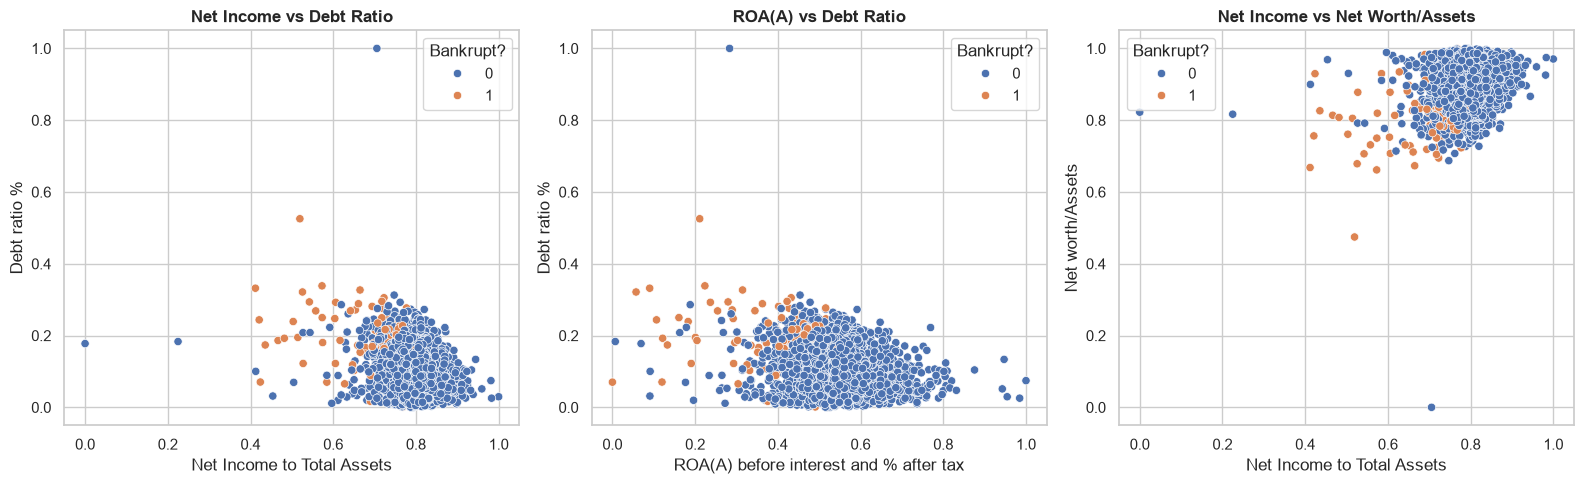

In [179]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16,5))

sns.scatterplot(
    data=df,
    x="Net Income to Total Assets",
    y='Debt ratio %',
    hue='Bankrupt?',
    ax=axes[0]
)
axes[0].set_title('Net Income vs Debt Ratio', fontweight='bold')

sns.scatterplot(
    data=df,
    x='ROA(A) before interest and % after tax',
    y='Debt ratio %',
    hue='Bankrupt?',
    ax=axes[1]
)
axes[1].set_title('ROA(A) vs Debt Ratio', fontweight='bold')

sns.scatterplot(
    data=df,
    x='Net Income to Total Assets',
    y='Net worth/Assets',
    hue='Bankrupt?',
    ax=axes[2]
)
axes[2].set_title('Net Income vs Net Worth/Assets', fontweight='bold')

plt.tight_layout()
plt.show()

1. Semakin kecil Net Incom to Total Assets dan semakin besar Debt Ratio % maka akan meningkatkan peluang bankruptcy
2. Semakin kecil ROA(A) before interest and % after tax dan semakin besar Debt Ratio % maka akan meningkatkan peluang bankruptcy
3. Semakin kecil Net Incom to Total Assets dan semakin kecil Net worth/Assets maka akan meningkatkan peluang bankruptcy

## Deteksi Outlier

In [180]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Bankrupt?', errors='ignore')

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum()

outlier_summary = pd.DataFrame({
    'Jumlah Outlier' : outliers_count,
    'Persentase' : (outliers_count / len(df) * 100).round(2)
}).sort_values(by='Jumlah Outlier', ascending=False)

fitur_ada_outlier = (outlier_summary['Jumlah Outlier'] > 0).sum()

print(outlier_summary.head(15))
print(fitur_ada_outlier)


                                                    Jumlah Outlier  Persentase
Degree of Financial Leverage (DFL)                            1503       22.04
Interest Coverage Ratio (Interest expense to EBIT)            1421       20.84
Fixed Assets Turnover Frequency                               1418       20.79
Current Asset Turnover Rate                                   1399       20.52
Total Asset Growth Rate                                       1381       20.25
Interest Expense Ratio                                        1362       19.97
Cash Flow to Liability                                        1212       17.77
No-credit Interval                                            1139       16.70
Non-industry income and expenditure/revenue                   1094       16.04
Cash Flow to Sales                                            1052       15.43
Continuous Net Profit Growth Rate                             1042       15.28
After-tax Net Profit Growth Rate                    

Persentase terbanyak ada di DFL, Interest Coverage Ratio (Interest expense to EBIT) , lalu Fixed Assets Turnover Frequency. Karena ada 89 fitur yang mempunyai outlier, maka decision tree sangat cocok karena tahan terhadap outlier

## Pengecekan Fitur Unik

In [181]:
unique_counts = df.nunique()
constant_cols = unique_counts[unique_counts == 1].index.tolist()

print(constant_cols)

['Net Income Flag']


Karena ada fitur yang hanya memiliki 1 nilai unik, maka fitur seperti itu tidak penting dan lebih baik di drop

In [182]:
df = df.drop(columns=['Net Income Flag'])

df.shape

(6819, 95)

## Matriks Korelasi

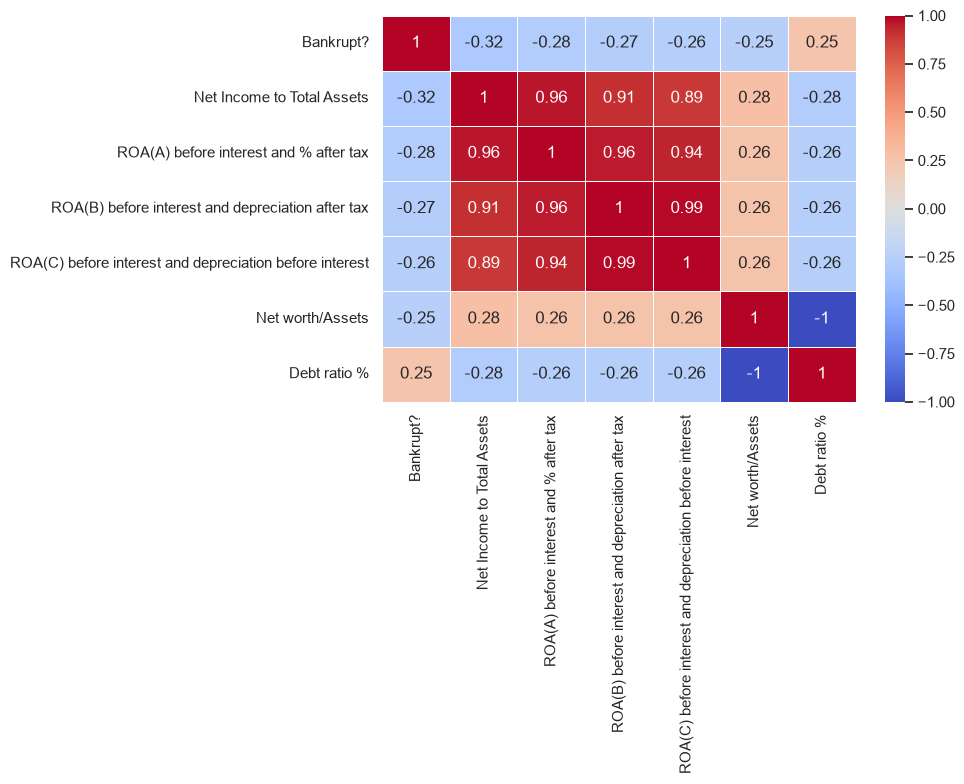

In [183]:
plt.figure(figsize=(10,8))
kolom_matrix_corr = ['Bankrupt?'] + top_features
corr_matrix = df[kolom_matrix_corr].corr()

sns.heatmap(
    data=corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2g',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.tight_layout()
plt.show()

Debt Ratio dengan Net worth/Assets memiliki korelasi -1, yang mana artinya kedua variabel ini bergerak secara berlawanan, dan jika mengetahui salah satunya maka kita pasti akan mengetahui kembarannya juga.

Lalu ada multikolinearitas diantara fitur ROA, serta Net Income to Total Assets dengan ROA(A), dikarenakan kita memakai model DecisionTree, maka tidak perlu khawatir karena model tersebut akan secara pintar memilih salah satu fitur terbaik saja.

Lalu korelasi terhadap fitur bankrupt? paling besar ada di -0.32 yang dimana jika semakin besar value fitur tersebut maka semakin mengurangi probabilitas kebangkrutan

# 2. Preprocessing

In [184]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

missing_count = df.isnull().sum().sum()
print(f"Total missing values pada dataset: {missing_count}")


Total missing values pada dataset: 0


Tidak ada missing value yang perlu ditangani

In [185]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Jumlah fitur kategorikal: {len(cat_cols)}")
print("Fitur kategorikal:", cat_cols)

Jumlah fitur kategorikal: 0
Fitur kategorikal: []


Tidak ada fitur kategorikal jadi tidak perlu di encoding

In [186]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah sampel Data Latih (X_train): {X_train.shape[0]} baris, {X_train.shape[1]} fitur")
print(f"Jumlah sampel Data Uji   (X_test) : {X_test.shape[0]} baris, {X_test.shape[1]} fitur")

print("\nProporsi kelas target pada Train Set (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nProporsi kelas target pada Test Set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Jumlah sampel Data Latih (X_train): 5455 baris, 94 fitur
Jumlah sampel Data Uji   (X_test) : 1364 baris, 94 fitur

Proporsi kelas target pada Train Set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

Proporsi kelas target pada Test Set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [187]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_gini.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [188]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)

print("=== METRIK EVALUASI: DECISION TREE (GINI) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gini, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gini, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_gini, zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gini, digits=4))


=== METRIK EVALUASI: DECISION TREE (GINI) ===
Accuracy : 0.9611
Precision: 0.3953
Recall   : 0.3864
F1-Score : 0.3908

Classification Report:
              precision    recall  f1-score   support

           0     0.9796    0.9803    0.9799      1320
           1     0.3953    0.3864    0.3908        44

    accuracy                         0.9611      1364
   macro avg     0.6875    0.6833    0.6854      1364
weighted avg     0.9607    0.9611    0.9609      1364



Karena data nya sangat imbalanced antara bankrupt dan tidak, maka accuracy nya tinggi, tetapi recall, precision, dan f1 score terhadap class yang bankrupt sangat rendah

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [189]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(
    criterion='entropy', 
    random_state=42
)

dt_entropy.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [190]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)

print("=== METRIK EVALUASI: DECISION TREE (ENTROPY) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_entropy):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_entropy, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_entropy, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_entropy, zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_entropy, digits=4))

=== METRIK EVALUASI: DECISION TREE (ENTROPY) ===
Accuracy : 0.9589
Precision: 0.3571
Recall   : 0.3409
F1-Score : 0.3488

Classification Report:
              precision    recall  f1-score   support

           0     0.9781    0.9795    0.9788      1320
           1     0.3571    0.3409    0.3488        44

    accuracy                         0.9589      1364
   macro avg     0.6676    0.6602    0.6638      1364
weighted avg     0.9580    0.9589    0.9585      1364



Seperti yang gini hasilkan, entropy pun mengalami hal yang sama karena data nya sangat imbalanced

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [191]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
depth_values = [1, 2, 3, 5, 10, None]

models_depth = {}

for depth in depth_values:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    models_depth[depth] = model

print("Selesai melatih semua model dengan variasi max_depth!")


Selesai melatih semua model dengan variasi max_depth!


In [192]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
accuracy_results = {
    'depth': [],
    'train_acc': [],
    'test_acc': []
}

for depth, model in models_depth.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    accuracy_results['depth'].append(str(depth))
    accuracy_results['train_acc'].append(train_acc)
    accuracy_results['test_acc'].append(test_acc)
    
    label_depth = "None" if depth is None else str(depth)
    print(f"max_depth = {label_depth:<6} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


max_depth = 1      | Train Acc: 0.9677 | Test Acc: 0.9677
max_depth = 2      | Train Acc: 0.9699 | Test Acc: 0.9699
max_depth = 3      | Train Acc: 0.9723 | Test Acc: 0.9714
max_depth = 5      | Train Acc: 0.9775 | Test Acc: 0.9692
max_depth = 10     | Train Acc: 0.9947 | Test Acc: 0.9611
max_depth = None   | Train Acc: 1.0000 | Test Acc: 0.9611


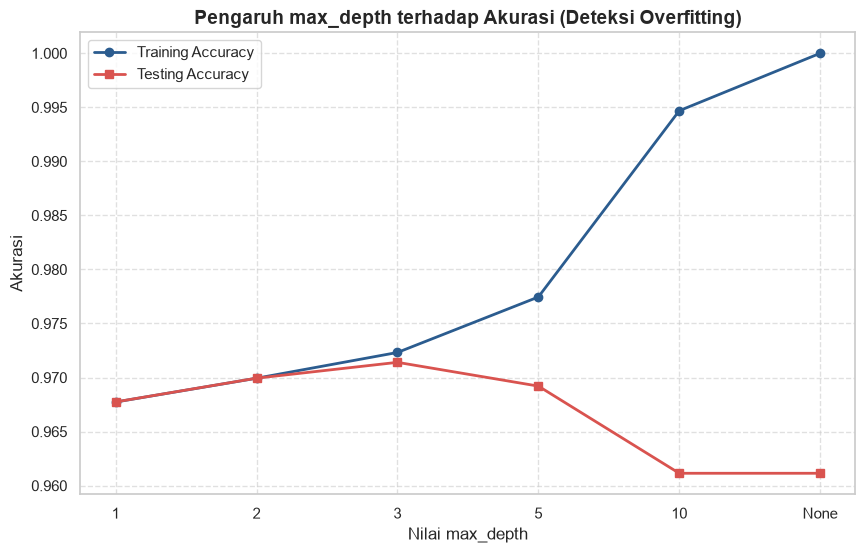

In [193]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(10, 6))

plt.plot(accuracy_results['depth'], accuracy_results['train_acc'], marker='o', label='Training Accuracy', color='#2b5c8f', linewidth=2)
plt.plot(accuracy_results['depth'], accuracy_results['test_acc'], marker='s', label='Testing Accuracy', color='#d9534f', linewidth=2)

plt.title('Pengaruh max_depth terhadap Akurasi (Deteksi Overfitting)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai max_depth', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Dilihat dari grafik dan eksperimen max_depthnya, jika max_depth dibiarkan terus bertumbuh tanpa batas atau semakin banyak max_depth nya, maka risiko overfitting terhadap data train membesar, dan itu menurunkan akurasi terhadap data testnya

# 4. Evaluasi Model

In [194]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

comparison_metrics = pd.DataFrame({
    'Kriteria Model': ['Decision Tree (Gini)', 'Decision Tree (Entropy)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy)
    ],
    'Precision': [
        precision_score(y_test, y_pred_gini, zero_division=0),
        precision_score(y_test, y_pred_entropy, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_gini, zero_division=0),
        recall_score(y_test, y_pred_entropy, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_gini, zero_division=0),
        f1_score(y_test, y_pred_entropy, zero_division=0)
    ]
}).round(4)

display(comparison_metrics)



,Kriteria Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Gini),0.9611,0.3953,0.3864,0.3908
1,Decision Tree (Entropy),0.9589,0.3571,0.3409,0.3488


Keduanya sama sama jelek di bagian selain accuracy karena class pada data tersebut sangat imbalanced

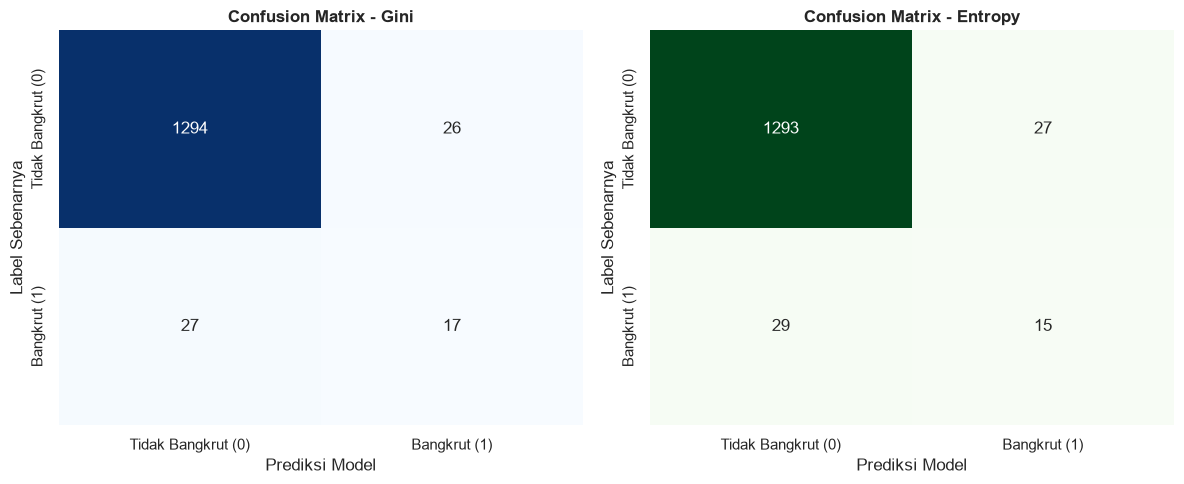

In [195]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.heatmap(
    cm_gini, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False, 
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix - Gini', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Label Sebenarnya')
axes[0].set_xticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])
axes[0].set_yticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])

sns.heatmap(
    cm_entropy, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False, 
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix - Entropy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Label Sebenarnya')
axes[1].set_xticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])
axes[1].set_yticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])

plt.tight_layout()
plt.show()


Bisa diliat prediksi nya kebanyakan tepat pada class yang tidak bangkrut, sementara model tidak bisa memprediksi class bangkrut dengan akurat

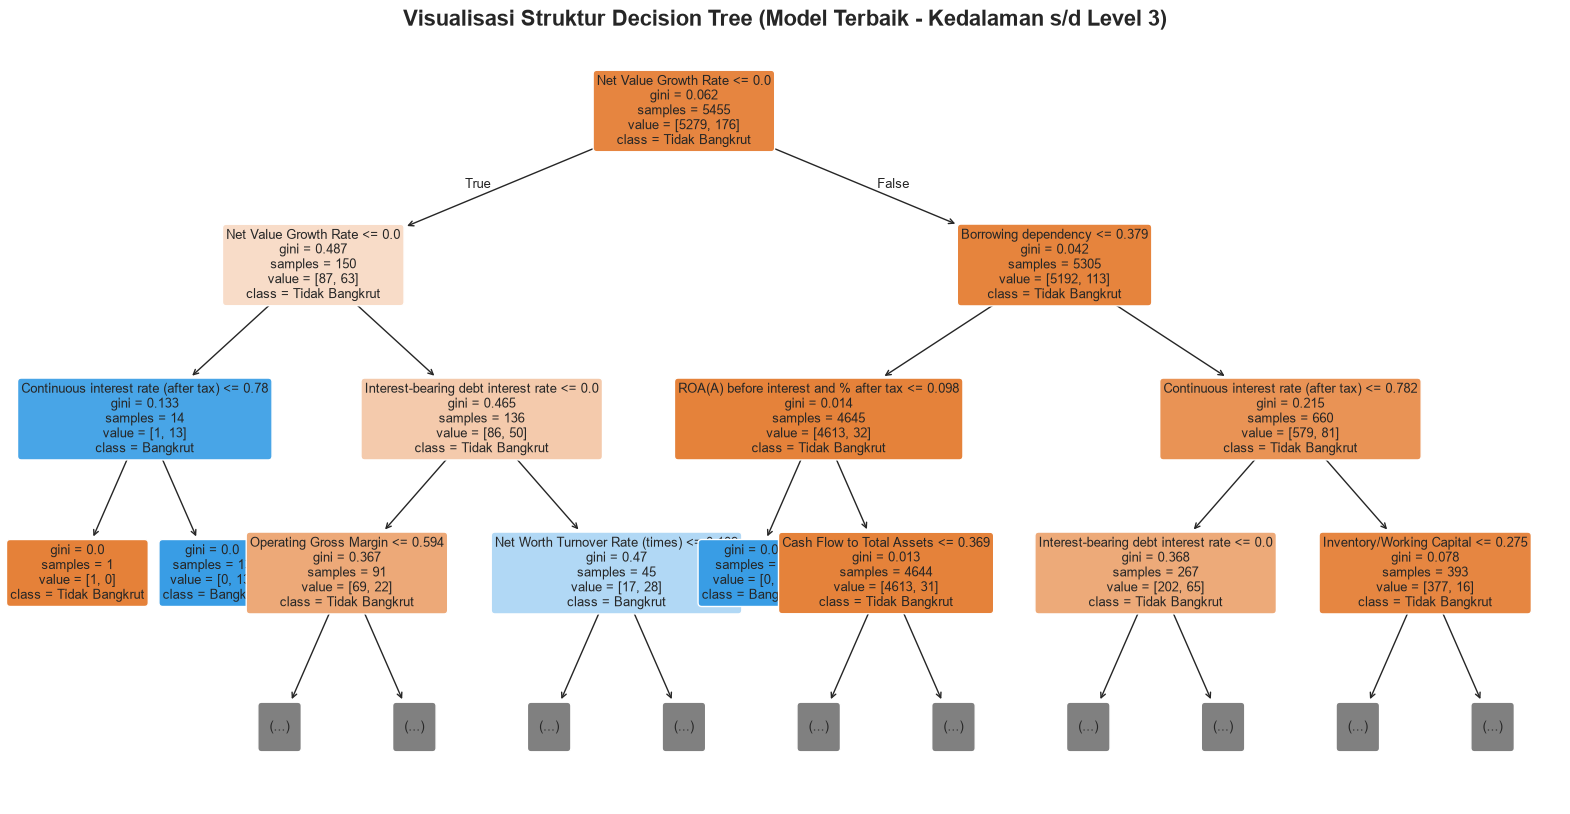

In [196]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
plt.figure(figsize=(20, 10))

plot_tree(
    dt_gini,
    max_depth=3,                          # Batasi kedalaman agar teks tidak menumpuk
    feature_names=X.columns.tolist(),      # Nama-nama fiturnya
    class_names=['Tidak Bangkrut', 'Bangkrut'], # Label kelasnya
    filled=True,                          # Warna node sesuai kelas mayoritas
    rounded=True,                         # Sudut kotak melengkung rapi
    fontsize=9
)

plt.title("Visualisasi Struktur Decision Tree (Model Terbaik - Kedalaman s/d Level 3)", fontsize=16, fontweight='bold')
plt.show()


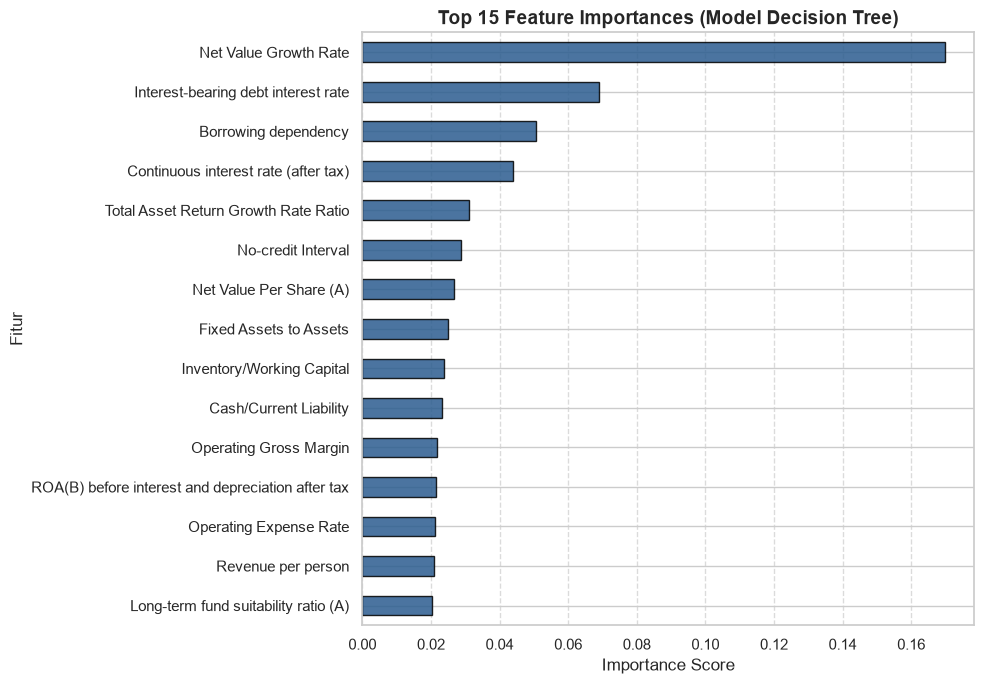

In [197]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = pd.Series(dt_gini.feature_importances_, index=X.columns)

top_importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
top_importances.plot(kind='barh', color='#2b5c8f', edgecolor='black', alpha=0.85)

plt.title('Top 15 Feature Importances (Model Decision Tree)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Net Value Growth Rate menjadi root node karena memberikan penurunan ketidakmurnian (Gini gain / information gain) terbesar di antara seluruh 95 fitur pada split pertama

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Performa Decision Tree dengan kriteria Gini dan Entropy tidak jauh berbeda bisa dilihat dari metriks evaluasinya, karena pada dasarnya mereka sama sama model Decision Tree, tetapi hanya beda pada cara memecah datanya. Gini mengukur probabilitas salah tebak jika sebuah label diambil secara acak, Entropy mengukur tingkat ketidakpastian data. Model dengan kriteria Gini Impurity mendapatkan F1 score yang lebih baik daripada entropy serta lebih cepat pada komputasi

Temuan dari eksperimen regulasi pada hyperparameter max_depth adalah semakin dalam kedalamannya maka tingkat overfitting terhadap data trainnya semakin meningkat, seperti pada contoh data tersebut, model mulai menunjukkan tanda tanda overfitting saat max_depth nya diberi value 5 sesuai dengan grafiknya. Ciri cirinya terlihat saat akurasi pada data trainnya itu mencapai 100 persen dan berbanding dengan test nya lebih kecil dari data trainnya, dan saat diberikan lebih dari 5 pada max_depth nya akurasi training mulai meroket naik ke 100 persen

Fitur paling berpengaruh terhadap prediksi model berdasarkan feature importancenya adalah Net Value Growth Rate, karena bisa memberika penurunan ketidakmurnian terbesar di antara seluruh fitur yang ada

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulan :
1. Kriteria Split: Model dengan kriteria Gini Impurity menghasilkan performa yang sedikit lebih baik (F1-Score 0.3908) dibandingkan Entropy (F1-Score 0.3488), serta lebih cepat dalam proses komputasi.
2. Regularisasi (max_depth): Pohon tanpa batas kedalaman (max_depth=None) mengalami overfitting (akurasi training 100%, tapi akurasi testing stagnan). Pembatasan max_depth di sekitar 3 hingga 5 terbukti efektif mencegah overfitting dan menjaga model tetap mudah dibaca.
3. Karakteristik Data: Decision Tree terbukti cocok untuk dataset ini karena kebal terhadap banyaknya *outlier* dan tidak membutuhkan *feature scaling*.
4. Fitur Paling Berpengaruh: Penentu utama kebangkrutan pada model adalah pertumbuhan nilai aset (Net Value Growth Rate) dan rasio ketergantungan utang (Borrowing dependency).

Saran :
Karena eksperimennya hanya pada hyperparameter max_depth nya saja dan tidak mencoba coba hyperparameter yang lainnya, maka dari itu untuk eksperimen selanjutnya bisa mencoba coba untuk hyperparameter yang lainnya seperti ccp_alpha, dll.